# Lesson 03：字串與數字題目整理

> 這份 notebook 的目標：練習把題目拆成「判斷條件 → 迴圈搜尋 → 輸出答案」。
>
> 本課會整理幾個 APCS / 程式競賽常見題型：
> 1. 完全奇數
> 2. 秘密差
> 3. 字串大小寫區段
> 4. 串列切片與分數判斷


---

## Section I. 完全奇數：判斷每一位是不是奇數

完全奇數的意思是：一個正整數的「每一個位數」都是奇數。

例如：
- `7` 是完全奇數。
- `13` 是完全奇數。
- `135` 是完全奇數。
- `25` 不是完全奇數，因為 `2` 是偶數。

核心想法：
1. 把數字轉成字串。
2. 一位一位檢查。
3. 只要發現偶數，就可以判定不是完全奇數。


### 複習提示

閱讀這段程式時，請特別注意兩件事：
1. `num` 是字串，所以可以用 `for digit in num` 一位一位讀。
2. `is_complete_odd` 是布林變數，用來記錄目前是否仍然符合條件。


In [ ]:
# 目標：判斷輸入的每一位數字是不是奇數
# 例：135 -> 每一位都是奇數，所以是完全奇數
# 例：25  -> 2 是偶數，所以不是完全奇數

num = input('請輸入一串數字：')

# 先假設它是完全奇數；如果後面發現偶數，再改成 False
is_complete_odd = True

# digit 會依序拿到字串中的每一個字元
# 例如 num = '135'，digit 會依序是 '1'、'3'、'5'
for digit in num:
    # int(digit) 把單一字元轉成數字
    # % 2 == 0 代表這個數字可以被 2 整除，也就是偶數
    if int(digit) % 2 == 0:
        is_complete_odd = False
        # 只要找到一個偶數，就已經確定不是完全奇數
        # 所以可以直接停止迴圈，避免多做不必要的檢查
        break

# 根據剛剛檢查的結果輸出答案
if is_complete_odd:
    print('完全奇數')
else:
    print('不是完全奇數')


---

## Section II. 先建立完全奇數清單

如果我們想找「最接近某個數字的完全奇數」，可以先產生一個範圍內所有的完全奇數。

步驟：
1. 設定搜尋範圍。
2. 從 `0` 跑到範圍上限。
3. 每個數字都檢查是否為完全奇數。
4. 如果是，就存進 `complete_odd_numbers`。


### 複習提示

這裡使用「先建立清單」的策略。優點是查詢時比較直覺；缺點是如果範圍很大，建立清單會花比較多時間。


In [ ]:
# 目標：先把某個範圍內的完全奇數全部找出來，存進串列
# 之後要查詢「最接近 N 的完全奇數」時，就可以直接使用這份清單

end_number = 35001 * 2  # 搜尋上限；乘以 2 是為了讓右邊也有足夠範圍可以找
complete_odd_numbers = []  # 用來存放所有找到的完全奇數

# number 會從 0 跑到 end_number - 1
for number in range(end_number):
    # 每檢查一個新數字，都要重新假設它是完全奇數
    is_complete_odd = True

    # str(number) 可以把數字轉成字串，方便一位一位檢查
    for digit in str(number):
        # 如果任何一位是偶數，這個 number 就不是完全奇數
        if int(digit) % 2 == 0:
            is_complete_odd = False
            break

    # 只有完全奇數才加入清單
    if is_complete_odd:
        complete_odd_numbers.append(number)


In [ ]:
# 印出剛剛建立好的完全奇數清單
# 學生複習時可以觀察：清單中的數字是否每一位都是奇數
print('完全奇數清單：')
print(complete_odd_numbers)


---

## Section III. 找最接近 N 的完全奇數

題目要求：給一個正整數 `N`，找出最靠近 `N` 的完全奇數 `K`，並輸出：

```python
abs(K - N)
```

想法：
- 如果 `N` 本身就是完全奇數，答案是 `0`。
- 如果不是，就找出剛好在 `N` 左右兩邊的完全奇數。
- 比較左邊距離與右邊距離，輸出比較小的距離。


In [ ]:
# 目標：找出 input_number 到最近完全奇數的距離
# 這個寫法會使用前面建立好的 complete_odd_numbers 清單

input_number = int(input('請輸入一串數字：'))

# 如果輸入的數字本身就是完全奇數，距離就是 0
if input_number in complete_odd_numbers:
    print(0)
else:
    # 依序檢查清單中相鄰的兩個完全奇數
    # left  是左邊的完全奇數
    # right 是右邊的完全奇數
    for i in range(len(complete_odd_numbers) - 1):
        left = complete_odd_numbers[i]
        right = complete_odd_numbers[i + 1]

        # 找到 input_number 被夾在哪兩個完全奇數之間
        if left < input_number < right:
            # 比較 input_number 距離左邊比較近，還是距離右邊比較近
            answer = min(abs(right - input_number), abs(input_number - left))
            print(answer)
            break


---

## Section IV. 更直覺的解法：往上找、往下找

另一種方法是不先建立完整清單，而是直接從 `N` 開始找：

- `up`：從 `N` 往上加，直到找到完全奇數。
- `down`：從 `N` 往下減，直到找到完全奇數。
- 最後比較兩邊距離。

這種寫法比較容易理解，也很適合初學者練習 `while` 迴圈。


![ChatGPT Image Jun 1 2026 from Material Maker.png](<attachment:ChatGPT Image Jun 1 2026 from Material Maker.png>)
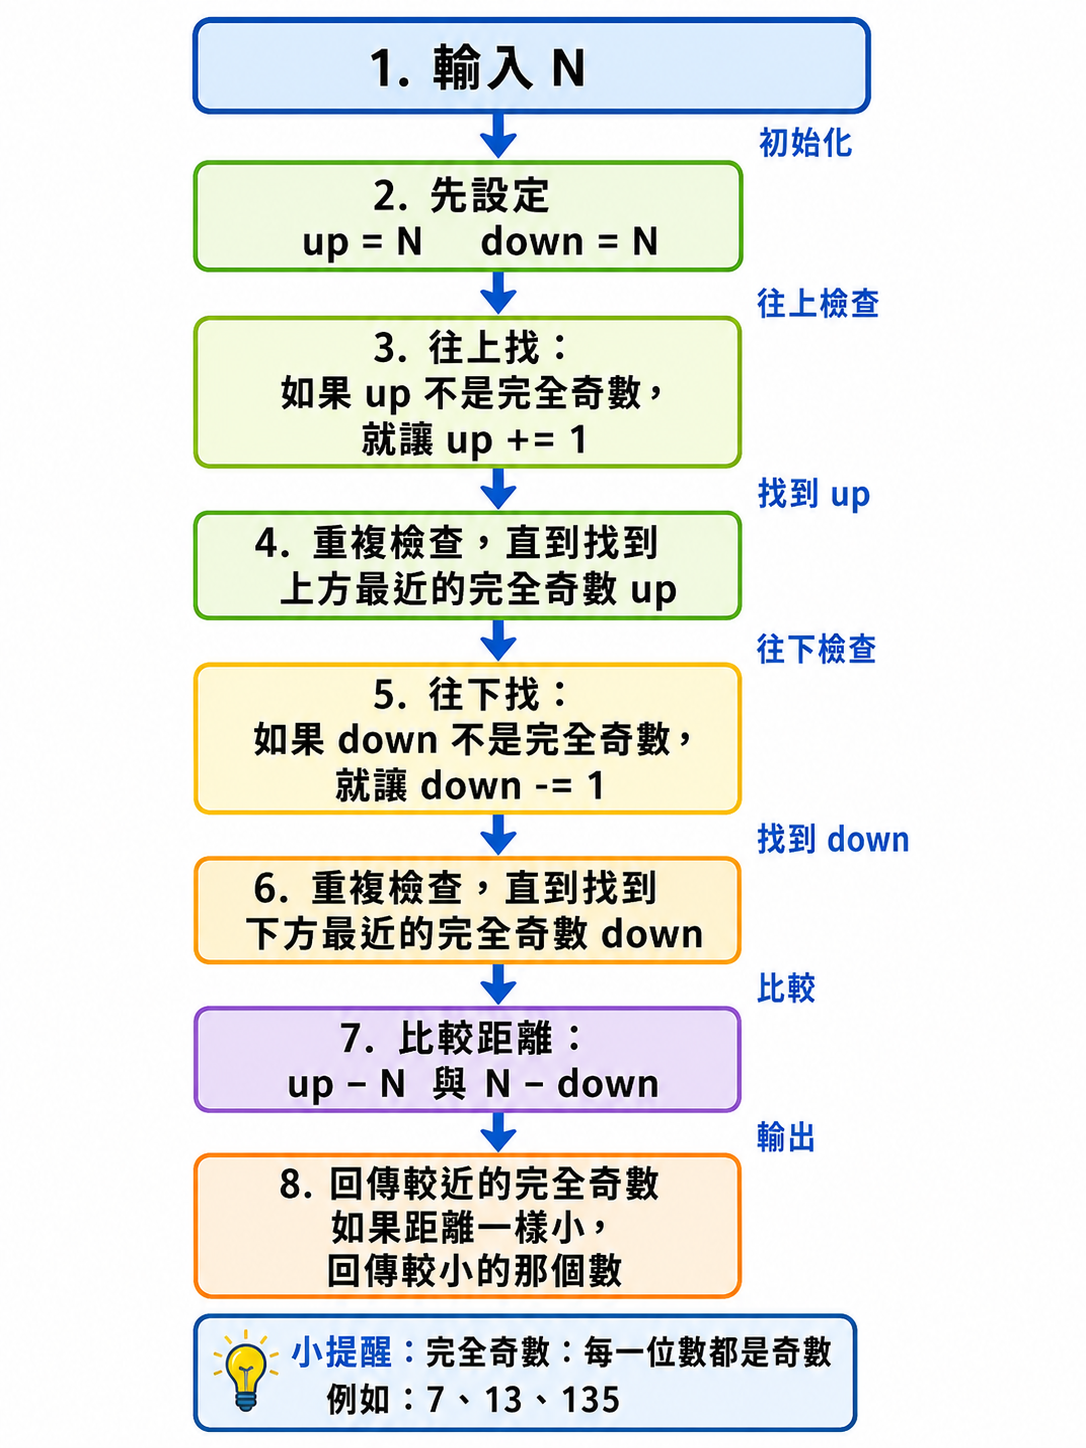

### 複習提示

`while` 很適合處理「不知道要找幾次才會找到答案」的情況。這題的停止條件是：找到完全奇數。


In [ ]:
def is_all_odd(num):
    """判斷一個整數的每一個位數是否都是奇數。"""
    # 函式的好處：同樣的檢查邏輯可以重複使用
    # 例如後面要檢查 up、down，都可以呼叫 is_all_odd()
    for digit in str(num):
        if int(digit) % 2 == 0:
            return False  # 只要有一位是偶數，就不是完全奇數
    return True  # 迴圈跑完都沒有遇到偶數，才代表全部都是奇數


# while True 通常用在「不知道會輸入幾筆資料」的題目
# 在競賽題中，常常會用 EOF 表示輸入結束
while True:
    try:
        input_number = int(input('請輸入一串數字：'))
    except EOFError:
        # 沒有更多輸入時，離開 while True
        break

    # 往上找：如果目前不是完全奇數，就一直 +1
    up = input_number
    while not is_all_odd(up):
        up += 1

    # 往下找：如果目前不是完全奇數，就一直 -1
    # down >= 0 是保護條件，避免數字變成負數後還繼續找
    down = input_number
    while down >= 0 and not is_all_odd(down):
        down -= 1

    # up - input_number 是往上找到的距離
    # input_number - down 是往下找到的距離
    # min(...) 取較小距離
    print(min(abs(up - input_number), abs(input_number - down)))


---

## Section V. 秘密差

題目概念：

將一個十進位正整數的：
- 奇數位數字總和記為 `A`
- 偶數位數字總和記為 `B`

最後輸出：

```python
abs(A - B)
```

注意：這裡的「奇數位」與「偶數位」是指第 1 位、第 2 位、第 3 位……，不是數字本身是奇數或偶數。


In [ ]:
# 目標：計算秘密差
# 注意：這裡的奇數位 / 偶數位是「位置」，不是數字本身的奇偶

n = input('請輸入一個正整數：')

odd_position_sum = 0   # 第 1、3、5... 位的數字總和
even_position_sum = 0  # 第 2、4、6... 位的數字總和

# enumerate(n) 會同時提供 index 和 digit
# index 從 0 開始，所以真正的位置要用 index + 1
for index, digit in enumerate(n):
    position = index + 1

    if position % 2 == 0:
        # 偶數位置：加到 even_position_sum
        even_position_sum += int(digit)
    else:
        # 奇數位置：加到 odd_position_sum
        odd_position_sum += int(digit)

# abs(...) 取絕對值，避免答案出現負數
print(abs(odd_position_sum - even_position_sum))


---

## Section VI. `enumerate()` 與 `reversed()` 小練習

`enumerate()` 可以同時拿到：
- 目前位置 `index`
- 目前元素 `value`

`reversed()` 可以把可迭代資料反過來讀。


In [ ]:
text = 'hello'

# reversed(text) 會把字串反過來讀：o, l, l, e, h
# enumerate(...) 會幫每個字元加上編號：0, 1, 2, ...
for index, char in enumerate(reversed(text)):
    print(index, char)


---

## Section VII. 字串大小寫區段題

這類題目常見要求：
- 給定一個長度 `k`
- 字串要切成一段一段，每段長度都是 `k`
- 每一段必須全大寫或全小寫
- 相鄰段落的大寫 / 小寫類型不能相同

核心工具：
- `s[start:start+k]`：取出長度為 `k` 的片段。
- `part.isupper()`：判斷片段是否全大寫。
- `part.islower()`：判斷片段是否全小寫。


### 複習提示

這題比較難，請用三個問題檢查自己是否看懂：
1. `start` 代表什麼？
2. `pos` 為什麼每次要加 `k`？
3. `last_type` 為什麼可以用來檢查相鄰區段是否交錯？


In [ ]:
# 目標：找出最長的合法大小寫交錯區段
# k：每一段的固定長度
# s：要檢查的字串

k = int(input())
s = input().strip()

n = len(s)
answer = 0  # 目前找到的最長合法長度

# start 代表從字串的哪一個位置開始切
# 嘗試每一個可能的起點，避免漏掉答案
for start in range(n):
    last_type = None  # 記錄上一段是 upper 還是 lower
    length = 0        # 從目前 start 開始，累積的合法長度
    pos = start       # 目前要切片的位置

    # pos + k <= n 表示還能切出完整長度 k 的片段
    while pos + k <= n:
        # 取出從 pos 開始、長度為 k 的片段
        part = s[pos:pos + k]

        # 判斷目前片段是全大寫，還是全小寫
        if part.isupper():
            current_type = 'upper'
        elif part.islower():
            current_type = 'lower'
        else:
            # 如果這段不是全大寫也不是全小寫，就不合法
            break

        # 相鄰兩段不能同樣都是大寫或同樣都是小寫
        if last_type == current_type:
            break

        # 走到這裡代表目前片段合法，所以把長度加上 k
        length += k
        answer = max(answer, length)

        # 更新上一段類型，並移動到下一段
        last_type = current_type
        pos += k

print(answer)


---

## Section VIII. 串列切片練習

串列切片語法：

```python
list_name[start:end]
```

注意：
- 會包含 `start`
- 不包含 `end`


In [ ]:
numbers = [2, 3, 3, 5, 6, 19, 24, 10, 23, 23, 45, 92, 87, 0]

# numbers[2:9] 代表從 index 2 取到 index 8
# 注意：包含左邊 2，不包含右邊 9
print(numbers[2:9])


---

## Section IX. 分數判斷：Win / Lose / Tie

輸入四行分數：
1. 第一局主隊分數
2. 第一局客隊分數
3. 第二局主隊分數
4. 第二局客隊分數

輸出：
- 每一局的總分
- 最後判斷 `Win`、`Lose` 或 `Tie`


In [ ]:
# 目標：讀入兩局比賽分數，判斷最後是 Win / Lose / Tie
# 每一行可能有多個數字，所以用 split() 拆開，再用 map(int, ...) 轉成整數
# sum(...) 會把同一行的分數加總

home_1 = sum(map(int, input().split()))  # 第一局主隊總分
away_1 = sum(map(int, input().split()))  # 第一局客隊總分
home_2 = sum(map(int, input().split()))  # 第二局主隊總分
away_2 = sum(map(int, input().split()))  # 第二局客隊總分

# 先輸出每一局的比分
print(f'{home_1}:{away_1}')
print(f'{home_2}:{away_2}')

win_count = 0   # 主隊贏了幾局
lose_count = 0  # 主隊輸了幾局

# 判斷第一局結果
if home_1 > away_1:
    win_count += 1
elif away_1 > home_1:
    lose_count += 1

# 判斷第二局結果
if home_2 > away_2:
    win_count += 1
elif away_2 > home_2:
    lose_count += 1

# 兩局都贏才是 Win；兩局都輸才是 Lose；其他情況是 Tie
if win_count == 2:
    print('Win')
elif lose_count == 2:
    print('Lose')
else:
    print('Tie')


---

## Section X. 課後整理

本課重點：

1. 數字題常常可以先轉成字串，再逐位處理。
2. `for` 適合跑固定範圍；`while` 適合「不知道要跑幾次，但知道停止條件」的情況。
3. `enumerate()` 可以同時取得位置與元素。
4. 字串切片 `s[start:end]` 很適合處理固定長度區段。
5. 寫程式時，變數名稱越清楚，越容易檢查邏輯。
